In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import matplotlib as mpl

### Inputs

In [2]:
# Inputs
geodata= pd.read_csv('../state_model/GeoData.txt', index_col=0, sep='\t')

fca = pd.read_csv('../hist_data/timeFCON_DD.txt', sep= '\t', skiprows=1, index_col=0)

pobs = pd.read_csv('../hist_data/timeCPRC_DD.txt', sep= '\t', skiprows=1, index_col=0)

evap = pd.read_csv('../hist_data/timeEVAP_DD.txt', sep= '\t', skiprows=1, index_col=0)

cout = pd.read_csv('../hist_data/timeCOUT_DD.txt', sep= '\t', skiprows=1, index_col=0)

cilv = pd.read_csv('/home/paul.coderre/research/SMM_Models/hype/model/v10_model/final_model/hds_v3/results/timeCILV_DD.txt', sep= '\t', skiprows=1, index_col=0)

gauge_ids = [58290, 58308, 58356, 58363]

start_year= 1985

end_year = 2015

output_dir = './new_plots/'

hype_id_to_location  = {
    '0058328': ('Milk River', 'BCBMO'),
    '0058346': ('Milk River', 'BSCMO'),
    '0058363': ('Milk River', 'BTCIB'),
    '0058425': ('Milk River', 'CLCMO'),
    '0058290': ('Milk River', 'FRRIB'),
    '0058356': ('Milk River', 'LDCIB'),
    '0058408': ('Milk River', 'MRWIB'),
    '0058643': ('Milk River', 'NFKMR'),
    '0058418': ('Milk River', 'PPCMO'),
    '0058398': ('Milk River', 'RKCMO'),
    '0058213': ('St. Mary', 'SMRBB'),
    '0058208': ('St. Mary', 'SMRIB'),
    '0058223': ('St. Mary', 'SWCSB'),
    '0058308': ('Milk River', 'MREIB'),
    '0058242': ('Milk River', 'Outlet')
}

### Pre Processing

In [3]:
# Unit conversions
geodata['maindown'] = geodata['maindown'].astype(int)
geodata.index= geodata.index.astype(int)

fca.index = pd.to_datetime(fca.index)
cilv.index = pd.to_datetime(cilv.index)
pobs.index = pd.to_datetime(pobs.index)
evap.index = pd.to_datetime(evap.index)
cout.index = pd.to_datetime(cout.index)

fca.columns = fca.columns.astype(int)
cilv.columns = cilv.columns.astype(int)
pobs.columns = pobs.columns.astype(int)
evap.columns = evap.columns.astype(int)
cout.columns = cout.columns.astype(int)

# Create a dictionary with subbasin ID and area
subbasin_area = geodata["area"].to_dict()

In [4]:
# Trim FCA
fca_trimmed = fca.loc[str(start_year):str(end_year)]
pobs_trimmed = pobs.loc[str(start_year):str(end_year)]
evap_trimmed = evap.loc[str(start_year):str(end_year)]
cout_trimmed = cout.loc[str(start_year):str(end_year)]

# Assuming `geodata` is already defined
# Create a directed graph
riv_graph = nx.DiGraph()

# Add edges from DataFrame
for idx, row in geodata.iterrows():
    if row['maindown'] != '0':  # Skip if maindown is '0'
        riv_graph.add_edge(idx, row['maindown'])

In [5]:
results = {}
for gauge_id in gauge_ids:
    upstream_segments = [int(n) for n in nx.ancestors(riv_graph, gauge_id)]
    upstream_segments.append(int(gauge_id))
    total_upstream_area = sum(subbasin_area[s] for s in upstream_segments if s in subbasin_area)

    # Depression storage
    upstream_cols_cilv = [col for col in cilv.columns if col in upstream_segments]
    total_vol = cilv[upstream_cols_cilv].sum(axis=1).sum()

    # Contributing area
    upstream_cols_fca = [col for col in fca_trimmed.columns if col in upstream_segments]
    con_area = fca_trimmed[upstream_cols_fca].mul(pd.Series(subbasin_area), axis=1)
    total_ca = con_area.sum(axis=1)
    total_fca = total_ca / total_upstream_area
    con_area = pd.concat([con_area, total_ca.rename('total_ca'), total_fca.rename('total_fca')], axis=1)

    # Area-weighted mean precipitation
    upstream_cols_pobs = [col for col in pobs_trimmed.columns if col in upstream_segments]
    weighted_precip = (
        pobs_trimmed[upstream_cols_pobs]
        .mul(pd.Series(subbasin_area), axis=1)
        .sum(axis=1) / total_upstream_area
    )

    # Area-weighted mean evaporation
    upstream_cols_evap = [col for col in evap_trimmed.columns if col in upstream_segments]
    weighted_evap = (
        evap_trimmed[upstream_cols_evap]
        .mul(pd.Series(subbasin_area), axis=1)
        .sum(axis=1) / total_upstream_area
    )

    results[gauge_id] = {
        'total_vol': total_vol,
        'total_upstream_area_km2': total_upstream_area / 1e6,
        'fca_timeseries': con_area[['total_ca', 'total_fca']],
        'precip': weighted_precip,
        'evap': weighted_evap
    }

### Plots

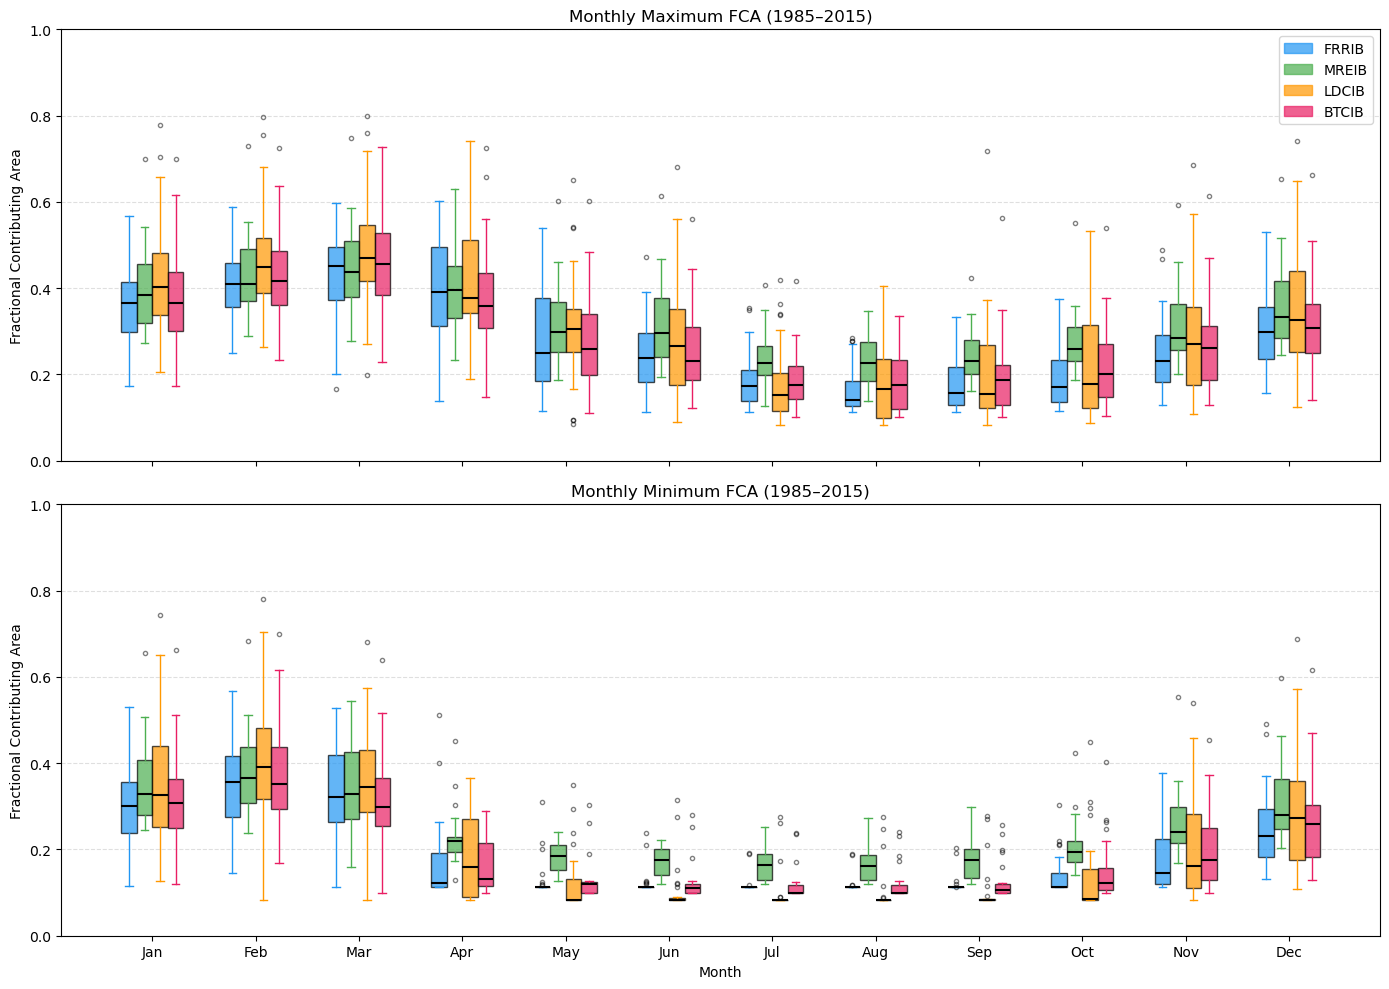

In [6]:
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
n_gauges = len(gauge_ids)
width = 0.15
offsets = np.linspace(-(n_gauges-1)*width/2, (n_gauges-1)*width/2, n_gauges)

fig, (ax_max, ax_min) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for i, gauge_id in enumerate(gauge_ids):
    name = hype_id_to_location[f'00{gauge_id}'][1]
    fca_ts = results[gauge_id]['fca_timeseries']['total_fca']

    for ax, func, label in [(ax_max, 'max', 'max'), (ax_min, 'min', 'min')]:
        monthly = (
            fca_ts.groupby([fca_ts.index.year, fca_ts.index.month])
            .agg(func)
            .rename_axis(['year', 'month'])
            .reset_index()
        )
        monthly_distributions = [
            monthly[monthly['month'] == m]['total_fca'].values
            for m in range(1, 13)
        ]
        positions = np.arange(1, 13) + offsets[i]
        ax.boxplot(monthly_distributions, positions=positions, widths=width,
                   patch_artist=True, manage_ticks=False,
                   boxprops=dict(facecolor=colors[i], alpha=0.7),
                   medianprops=dict(color='black', linewidth=1.5),
                   whiskerprops=dict(color=colors[i]),
                   capprops=dict(color=colors[i]),
                   flierprops=dict(marker='o', color=colors[i], markersize=3, alpha=0.5))

legend_handles = [mpatches.Patch(color=colors[i], alpha=0.7, 
                                  label=hype_id_to_location[f'00{gauge_ids[i]}'][1])
                  for i in range(n_gauges)]

ax_max.set_ylabel('Fractional Contributing Area')
ax_max.set_title('Monthly Maximum FCA (1985–2015)')
ax_max.set_ylim(0, 1)
ax_max.legend(handles=legend_handles)
ax_max.grid(axis='y', linestyle='--', alpha=0.4)

ax_min.set_ylabel('Fractional Contributing Area')
ax_min.set_title('Monthly Minimum FCA (1985–2015)')
ax_min.set_ylim(0, 1)
ax_min.set_xticks(range(1, 13))
ax_min.set_xticklabels(month_labels)
ax_min.set_xlabel('Month')
ax_min.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(f'{output_dir}/Fig5_fca_monthly_boxplot.png', dpi=150, bbox_inches='tight')
plt.savefig(f'{output_dir}/Fig5_fca_monthly_boxplot.pdf', bbox_inches='tight')
plt.show()

### Winter Increasing CA Diagnosis

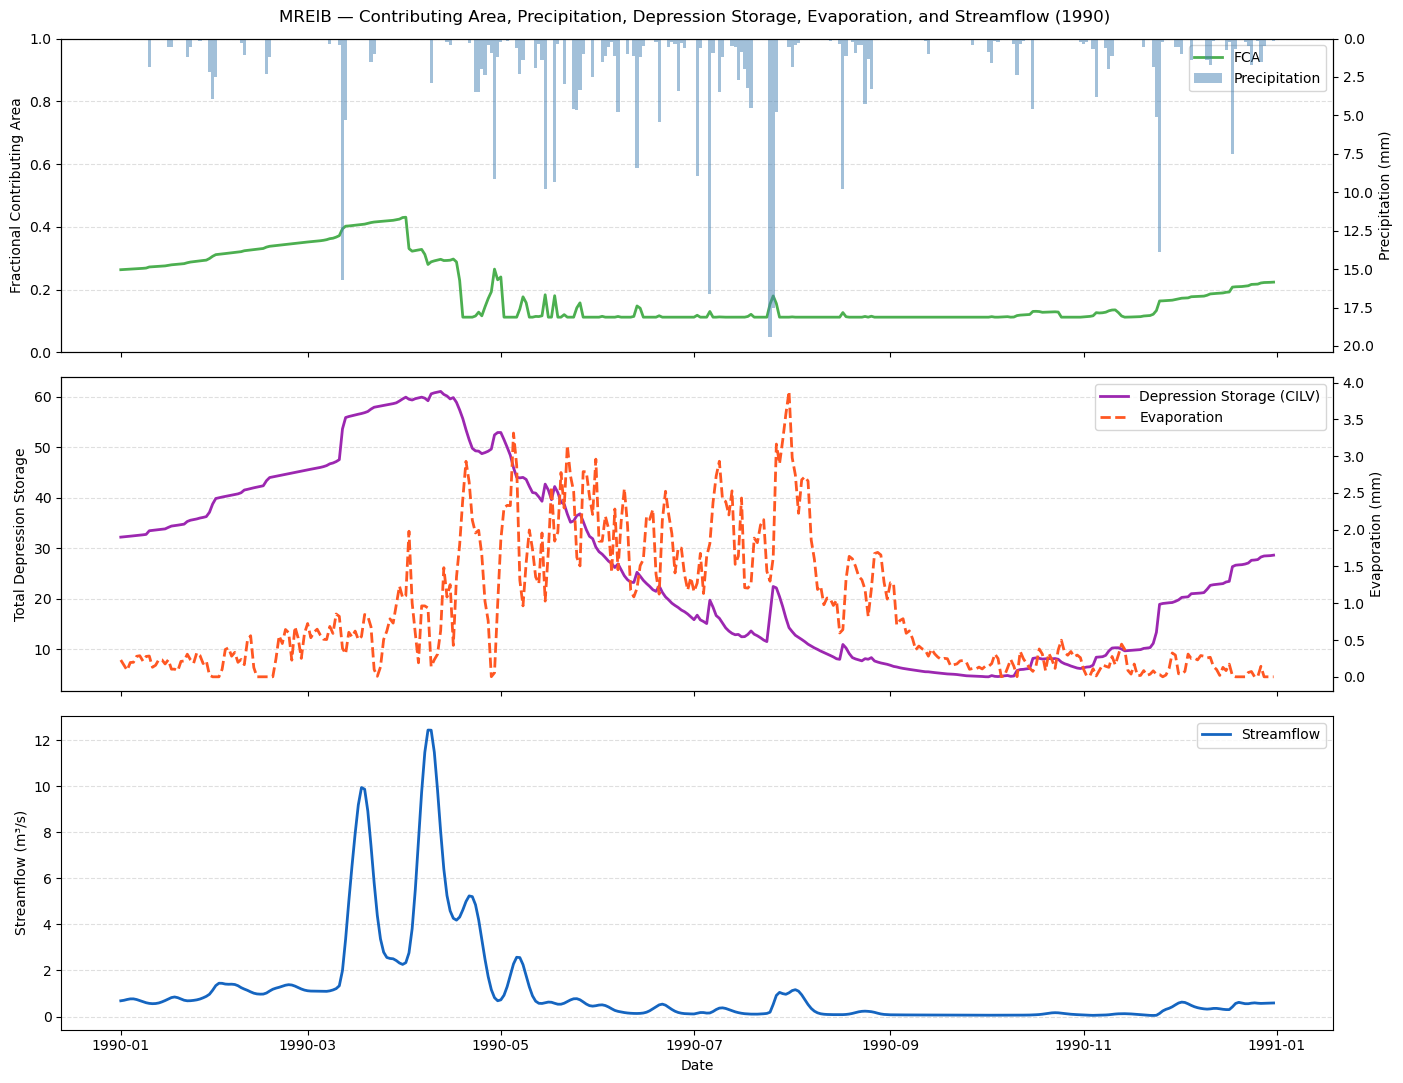

In [7]:
gauge_id = 58290  # MREIB
color = '#4CAF50'

mask = lambda ts: ts[ts.index.year == 1990]

fca_ts = mask(results[gauge_id]['fca_timeseries']['total_fca'])
precip_ts = mask(results[gauge_id]['precip'])
evap_ts = mask(results[gauge_id]['evap'])

upstream_segments = [int(n) for n in nx.ancestors(riv_graph, gauge_id)]
upstream_segments.append(int(gauge_id))
upstream_cols_cilv = [col for col in cilv.columns if col in upstream_segments]
cilv_ts = mask(cilv[upstream_cols_cilv].sum(axis=1))

# Streamflow for MREIB
# Streamflow for MREIB
cout.index = pd.to_datetime(cout.index)
streamflow_ts = mask(cout[gauge_id])
streamflow_ts = mask(cout[gauge_id])

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

# --- Panel 1: FCA + inverted precip ---
ax1.plot(fca_ts.index, fca_ts.values, color=color, linewidth=2, label='FCA')
ax1.set_ylabel('Fractional Contributing Area')
ax1.set_ylim(0, 1)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax1p = ax1.twinx()
ax1p.bar(precip_ts.index, precip_ts.values, color='steelblue', alpha=0.5, width=1, label='Precipitation')
ax1p.set_ylabel('Precipitation (mm)')
ax1p.invert_yaxis()

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1p.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# --- Panel 2: CILV + Evap ---
ax2.plot(cilv_ts.index, cilv_ts.values, color='#9C27B0', linewidth=2, label='Depression Storage (CILV)')
ax2.set_ylabel('Total Depression Storage')
ax2.grid(axis='y', linestyle='--', alpha=0.4)

ax2e = ax2.twinx()
ax2e.plot(evap_ts.index, evap_ts.values, color='#FF5722', linewidth=2, linestyle='--', label='Evaporation')
ax2e.set_ylabel('Evaporation (mm)')

lines3, labels3 = ax2.get_legend_handles_labels()
lines4, labels4 = ax2e.get_legend_handles_labels()
ax2.legend(lines3 + lines4, labels3 + labels4, loc='upper right')

# --- Panel 3: Streamflow ---
ax3.plot(streamflow_ts.index, streamflow_ts.values, color='#1565C0', linewidth=2, label='Streamflow')
ax3.set_ylabel('Streamflow (m³/s)')
ax3.set_xlabel('Date')
ax3.grid(axis='y', linestyle='--', alpha=0.4)
ax3.legend(loc='upper right')

fig.suptitle('MREIB — Contributing Area, Precipitation, Depression Storage, Evaporation, and Streamflow (1990)')
plt.tight_layout()
plt.show()